# Step-1 Business Problem Understanding

- Analytical Report

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [67]:
df = pd.read_csv("LoanData.csv")
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [68]:
df.shape

(614, 13)

In [69]:
df.columns.tolist()

['Loan_ID',
 'Gender',
 'Married',
 'Dependents',
 'Education',
 'Self_Employed',
 'ApplicantIncome',
 'CoapplicantIncome',
 'LoanAmount',
 'Loan_Amount_Term',
 'Credit_History',
 'Property_Area',
 'Loan_Status']

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [71]:
df["Loan_ID"].unique()

array(['LP001002', 'LP001003', 'LP001005', 'LP001006', 'LP001008',
       'LP001011', 'LP001013', 'LP001014', 'LP001018', 'LP001020',
       'LP001024', 'LP001027', 'LP001028', 'LP001029', 'LP001030',
       'LP001032', 'LP001034', 'LP001036', 'LP001038', 'LP001041',
       'LP001043', 'LP001046', 'LP001047', 'LP001050', 'LP001052',
       'LP001066', 'LP001068', 'LP001073', 'LP001086', 'LP001087',
       'LP001091', 'LP001095', 'LP001097', 'LP001098', 'LP001100',
       'LP001106', 'LP001109', 'LP001112', 'LP001114', 'LP001116',
       'LP001119', 'LP001120', 'LP001123', 'LP001131', 'LP001136',
       'LP001137', 'LP001138', 'LP001144', 'LP001146', 'LP001151',
       'LP001155', 'LP001157', 'LP001164', 'LP001179', 'LP001186',
       'LP001194', 'LP001195', 'LP001197', 'LP001198', 'LP001199',
       'LP001205', 'LP001206', 'LP001207', 'LP001213', 'LP001222',
       'LP001225', 'LP001228', 'LP001233', 'LP001238', 'LP001241',
       'LP001243', 'LP001245', 'LP001248', 'LP001250', 'LP0012

In [72]:
df["Gender"].unique()

array(['Male', 'Female', nan], dtype=object)

In [73]:
df["Gender"].value_counts()

Gender
Male      489
Female    112
Name: count, dtype: int64

In [74]:
df["Married"].unique()

array(['No', 'Yes', nan], dtype=object)

In [75]:
df["Married"].value_counts()

Married
Yes    398
No     213
Name: count, dtype: int64

In [76]:
df["Dependents"].unique()

array(['0', '1', '2', '3+', nan], dtype=object)

In [77]:
df["Dependents"].value_counts()

Dependents
0     345
1     102
2     101
3+     51
Name: count, dtype: int64

In [78]:
df["Education"].unique()

array(['Graduate', 'Not Graduate'], dtype=object)

In [79]:
df["Education"].value_counts()

Education
Graduate        480
Not Graduate    134
Name: count, dtype: int64

In [80]:
df["Self_Employed"].unique()

array(['No', 'Yes', nan], dtype=object)

In [81]:
df["Self_Employed"].value_counts()

Self_Employed
No     500
Yes     82
Name: count, dtype: int64

In [82]:
df["ApplicantIncome"].nunique()

505

In [83]:
df["CoapplicantIncome"] = df["CoapplicantIncome"].astype(int)
df["CoapplicantIncome"].unique()

array([    0,  1508,  2358,  4196,  1516,  2504,  1526, 10968,   700,
        1840,  8106,  2840,  1086,  3500,  5625,  1911,  1917,  2925,
        2253,  1040,  2083,  3369,  1667,  3000,  2067,  1330,  1459,
        7210,  1668,  1213,  2336,  3440,  2275,  1644,  1167,  1591,
        2200,  2250,  2859,  3796,  3449,  4595,  2254,  3066,  1875,
        1774,  4750,  3022,  4000,  2166,  1881,  2531,  2000,  2118,
        4167,  2900,  5654,  1820,  2302,   997,  3541,  3263,  3806,
        3583,   754,  1030,  1126,  3600,  2333,  4114,  2283,  1398,
        2142,  2667,  8980,  2014,  1640,  3850,  2569,  1929,  7750,
        1430,  2034,  4486,  1425,  1666,   830,  3750,  1041,  1280,
        1447,  3166,  3333,  1769,   736,  1964,  1619, 11300,  1451,
        7250,  5063,  2138,  5296,  2583,  2365,  2816,  2500,  1083,
        1250,  3021,   983,  1800,  1775,  2383,  1717,  2791,  1010,
        1695,  2054,  2598,  1779,  1260,  5000,  1983,  5701,  1300,
        4417,  4333,

In [84]:
df["LoanAmount"].unique()

array([ nan, 128.,  66., 120., 141., 267.,  95., 158., 168., 349.,  70.,
       109., 200., 114.,  17., 125., 100.,  76., 133., 115., 104., 315.,
       116., 112., 151., 191., 122., 110.,  35., 201.,  74., 106., 320.,
       144., 184.,  80.,  47.,  75., 134.,  96.,  88.,  44., 286.,  97.,
       135., 180.,  99., 165., 258., 126., 312., 136., 172.,  81., 187.,
       113., 176., 130., 111., 167., 265.,  50., 210., 175., 131., 188.,
        25., 137., 160., 225., 216.,  94., 139., 152., 118., 185., 154.,
        85., 259., 194.,  93., 370., 182., 650., 102., 290.,  84., 242.,
       129.,  30., 244., 600., 255.,  98., 275., 121.,  63., 700.,  87.,
       101., 495.,  67.,  73., 260., 108.,  58.,  48., 164., 170.,  83.,
        90., 166., 124.,  55.,  59., 127., 214., 240.,  72.,  60., 138.,
        42., 280., 140., 155., 123., 279., 192., 304., 330., 150., 207.,
       436.,  78.,  54.,  89., 143., 105., 132., 480.,  56., 159., 300.,
       376., 117.,  71., 490., 173.,  46., 228., 30

In [85]:
df["Loan_Amount_Term"].unique()

array([360., 120., 240.,  nan, 180.,  60., 300., 480.,  36.,  84.,  12.])

In [86]:
df["Loan_Amount_Term"].value_counts()

Loan_Amount_Term
360.0    512
180.0     44
480.0     15
300.0     13
84.0       4
240.0      4
120.0      3
60.0       2
36.0       2
12.0       1
Name: count, dtype: int64

In [87]:
df["Credit_History"].unique()

array([ 1.,  0., nan])

In [88]:
df["Credit_History"] = df["Credit_History"].replace({1:"Yes",0:"No"})

In [89]:
df["Credit_History"].value_counts()

Credit_History
Yes    475
No      89
Name: count, dtype: int64

In [59]:
df["Property_Area"].unique()

array(['Urban', 'Rural', 'Semiurban'], dtype=object)

In [60]:
df["Property_Area"].value_counts()

Property_Area
Semiurban    233
Urban        202
Rural        179
Name: count, dtype: int64

In [61]:
df["Loan_Status"].unique()

array(['Y', 'N'], dtype=object)

In [62]:
df["Loan_Status"].value_counts()

Loan_Status
Y    422
N    192
Name: count, dtype: int64

In [63]:
df.columns.tolist()

['Loan_ID',
 'Gender',
 'Married',
 'Dependents',
 'Education',
 'Self_Employed',
 'ApplicantIncome',
 'CoapplicantIncome',
 'LoanAmount',
 'Loan_Amount_Term',
 'Credit_History',
 'Property_Area',
 'Loan_Status']

In [91]:
df["overall_income"] = df['ApplicantIncome'] + df['CoapplicantIncome']

df.drop(columns=['ApplicantIncome','CoapplicantIncome'], inplace=True)

df

KeyError: 'ApplicantIncome'

In [93]:
continous = ['overall_income','LoanAmount']
count = ['Dependents','Loan_Amount_Term']
categorical = ['Gender','Married','Education','Self_Employed','Credit_History','Property_Area', 'Loan_Status']

In [94]:
df[continous].describe()

,overall_income,LoanAmount
count,614.000000,592.000000
mean,7024.703583,146.412162
std,6458.664751,85.587325
min,1442.000000,9.000000
25%,4166.000000,100.000000
50%,5416.500000,128.000000
75%,7521.750000,168.000000
max,81000.000000,700.000000


In [95]:
df[categorical].describe()

,Gender,Married,Education,Self_Employed,Credit_History,Property_Area,Loan_Status
count,601,611,614,582,564,614,614
unique,2,2,2,2,2,3,2
top,Male,Yes,Graduate,No,Yes,Semiurban,Y
freq,489,398,480,500,475,233,422


In [38]:
df.isnull().sum()

Gender              13
Married              3
Dependents          15
Education            0
Self_Employed       32
LoanAmount          22
Loan_Amount_Term    14
Credit_History      50
Property_Area        0
Loan_Status          0
overall_income       0
dtype: int64

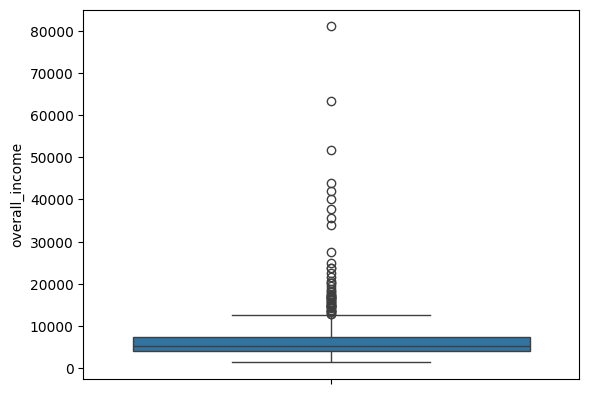

In [39]:
sns.boxplot(df["overall_income"])
plt.show()

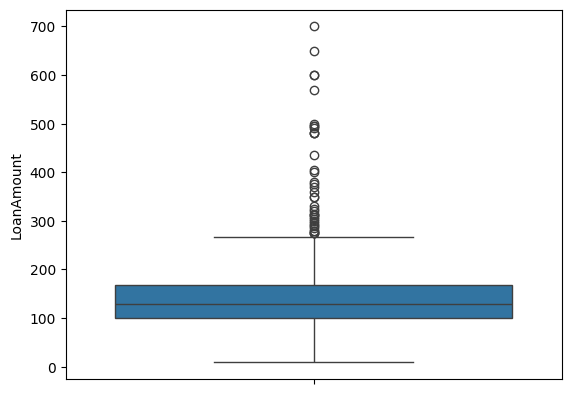

In [40]:
sns.boxplot(df['LoanAmount'])
plt.show()

In [41]:
df[continous].skew()

overall_income    5.633447
LoanAmount        2.677552
dtype: float64

In [42]:
df.duplicated().sum()

np.int64(0)

# Data Cleaning

In [96]:
df["Dependents"] = df["Dependents"].replace({"3+":3})

**Treat missing Values**

In [99]:
df["Gender"] = df["Gender"].fillna(df["Gender"].mode())
df["Married"] = df["Married"].fillna(df["Married"].mode())
df = df.dropna()

**Treat wrong Data Type**

In [100]:
df["Dependents"] = df["Dependents"].astype(int)
df["Loan_Amount_Term"] = df["Loan_Amount_Term"].astype(int)

C:\Users\utkar\AppData\Local\Temp\ipykernel_11984\1778409244.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Dependents"] = df["Dependents"].astype(int)
C:\Users\utkar\AppData\Local\Temp\ipykernel_11984\1778409244.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Loan_Amount_Term"] = df["Loan_Amount_Term"].astype(int)


**treat the outliers**

In [43]:
#retrain the outliers

In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 480 entries, 1 to 613
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Loan_ID           480 non-null    object 
 1   Gender            480 non-null    object 
 2   Married           480 non-null    object 
 3   Dependents        480 non-null    int64  
 4   Education         480 non-null    object 
 5   Self_Employed     480 non-null    object 
 6   LoanAmount        480 non-null    float64
 7   Loan_Amount_Term  480 non-null    int64  
 8   Credit_History    480 non-null    object 
 9   Property_Area     480 non-null    object 
 10  Loan_Status       480 non-null    object 
 11  overall_income    480 non-null    int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 48.8+ KB


# Data Analysis

- Measures + Plots
- Univariate, Bivariate , Multivariate

**Applying various questions or logics on dataset**

In [102]:
#1
df["Gender"].value_counts()

Gender
Male      394
Female     86
Name: count, dtype: int64

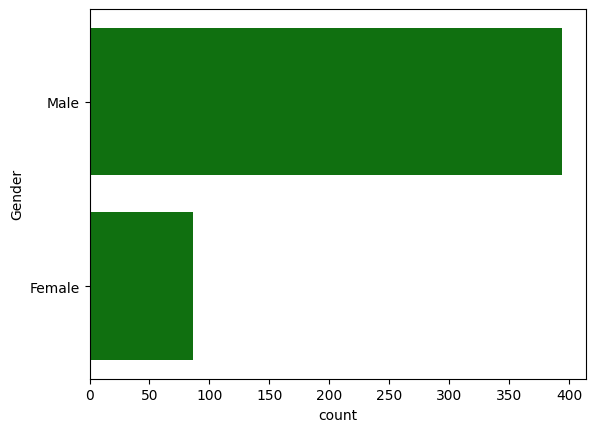

In [104]:
sns.countplot(df["Gender"],color = 'green')
plt.show()

In [105]:
df["Gender"].value_counts()/len(df)

Gender
Male      0.820833
Female    0.179167
Name: count, dtype: float64

- observation: 

In [106]:
df["Education"].value_counts()

Education
Graduate        383
Not Graduate     97
Name: count, dtype: int64

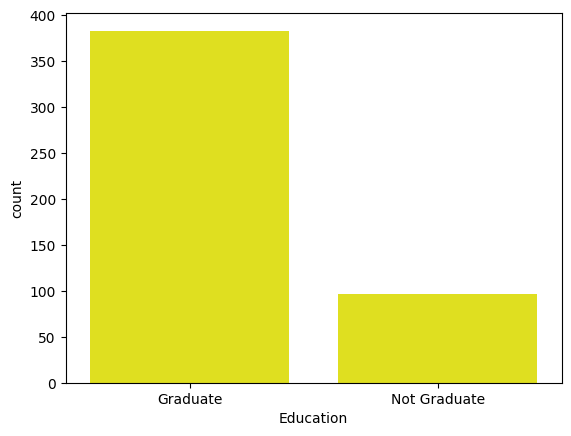

In [107]:
sns.countplot(x=df["Education"],color='yellow')
plt.show()

In [49]:
df["Education"].value_counts(normalize=True)

Education
Graduate        0.781759
Not Graduate    0.218241
Name: proportion, dtype: float64

List of Important Observations
- 

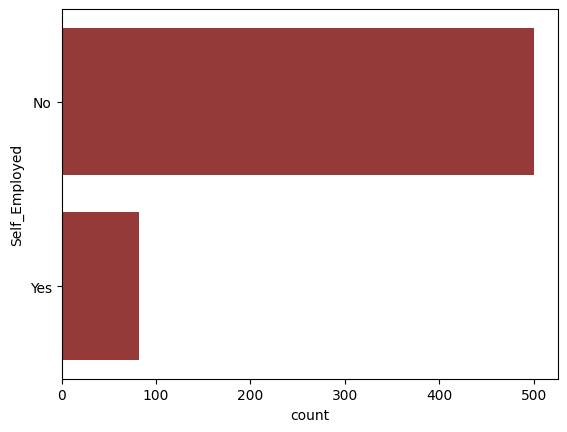

In [50]:
sns.countplot(df["Self_Employed"],stat='count',color="brown")
plt.show()

In [51]:
df['Self_Employed'].value_counts()

Self_Employed
No     500
Yes     82
Name: count, dtype: int64

In [108]:
df["Dependents"].value_counts()

Dependents
0    274
2     85
1     80
3     41
Name: count, dtype: int64

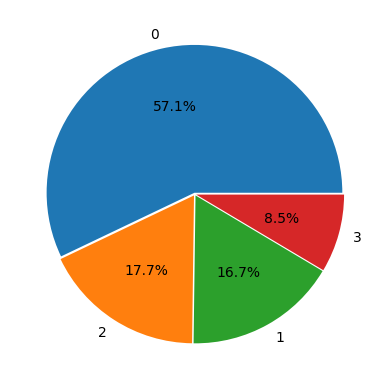

In [116]:
plt.pie(df["Dependents"].value_counts(),labels=[0,2,1,3],autopct="%0.1f%%",explode=[0.01,0.01,0.01,0.01])
plt.show()

In [117]:
df["Dependents"].value_counts()



Dependents
0    274
2     85
1     80
3     41
Name: count, dtype: int64

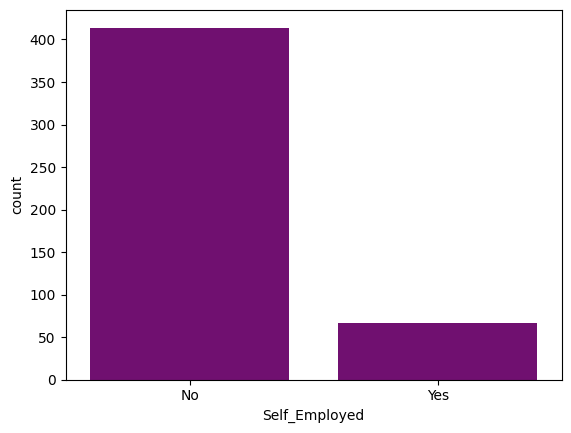

In [118]:
sns.countplot(x=df["Self_Employed"],color="purple")
plt.show()

In [119]:
df['Self_Employed'].value_counts()

Self_Employed
No     414
Yes     66
Name: count, dtype: int64

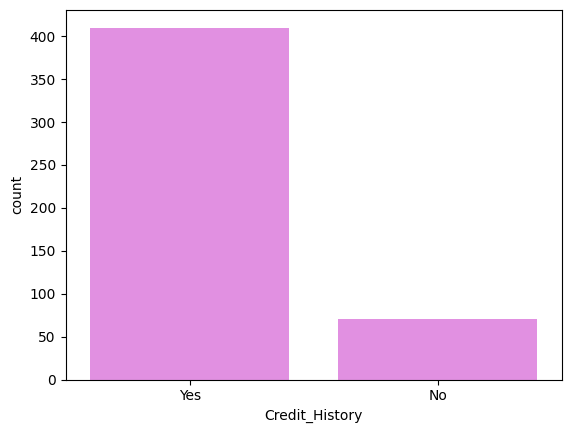

In [120]:
sns.countplot(x=df["Credit_History"],color="violet")
plt.show()

In [121]:
df['Credit_History'].value_counts()

Credit_History
Yes    410
No      70
Name: count, dtype: int64

<Axes: xlabel='LoanAmount', ylabel='Count'>

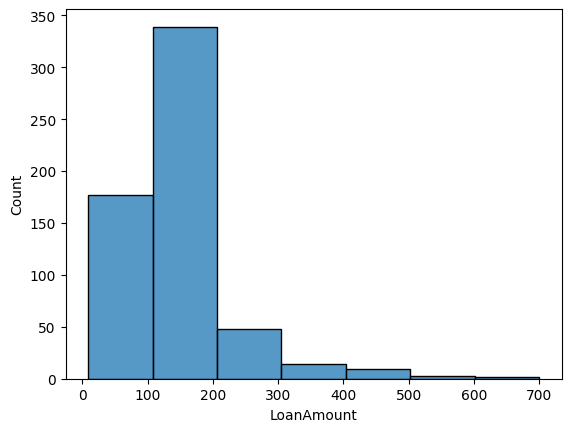

In [58]:
sns.histplot(df['LoanAmount'],bins=7)

In [59]:
df['LoanAmount'].describe()

count    592.000000
mean     146.412162
std       85.587325
min        9.000000
25%      100.000000
50%      128.000000
75%      168.000000
max      700.000000
Name: LoanAmount, dtype: float64

<Axes: xlabel='overall_income', ylabel='Count'>

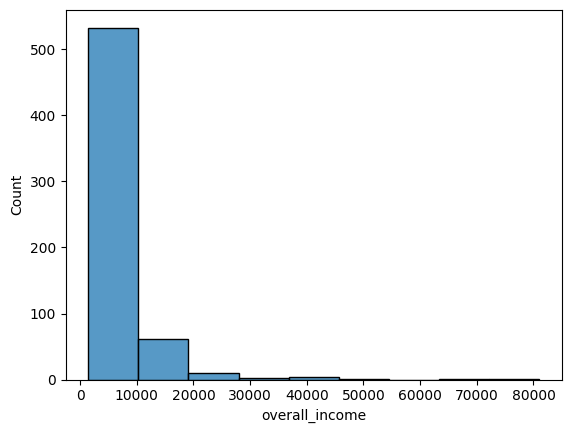

In [60]:
sns.histplot(df['overall_income'],bins=9)

In [61]:
df['overall_income'].describe()

count      614.000000
mean      7024.703583
std       6458.664751
min       1442.000000
25%       4166.000000
50%       5416.500000
75%       7521.750000
max      81000.000000
Name: overall_income, dtype: float64

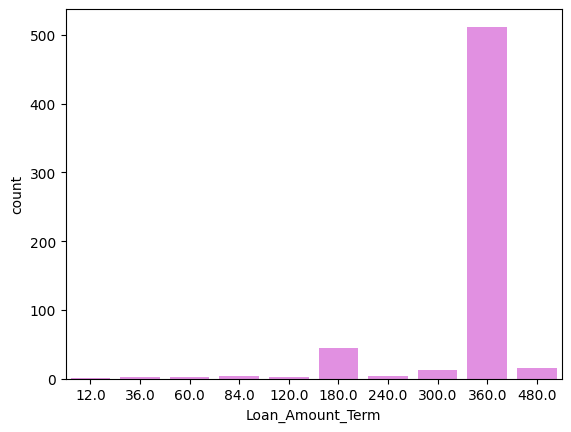

In [62]:
sns.countplot(x=df["Loan_Amount_Term"],color="violet")
plt.show()

In [63]:
df['Loan_Amount_Term'].value_counts()

Loan_Amount_Term
360.0    512
180.0     44
480.0     15
300.0     13
84.0       4
240.0      4
120.0      3
60.0       2
36.0       2
12.0       1
Name: count, dtype: int64

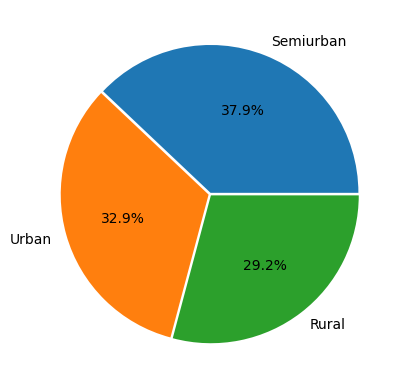

In [64]:
plt.pie(df["Property_Area"].value_counts(),labels=['Semiurban', 'Urban', 'Rural']
,autopct="%0.1f%%",explode=[0.01,0.01,0.01])
plt.show()

In [65]:
df['Property_Area'].value_counts()

Property_Area
Semiurban    233
Urban        202
Rural        179
Name: count, dtype: int64

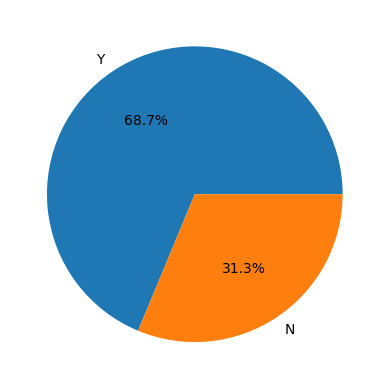

In [66]:
plt.pie(df["Loan_Status"].value_counts(),labels=['Y','N']
,autopct="%0.1f%%")
plt.show()

In [67]:
df["Loan_Status"].value_counts()

Loan_Status
Y    422
N    192
Name: count, dtype: int64

<Axes: xlabel='Loan_Status', ylabel='LoanAmount'>

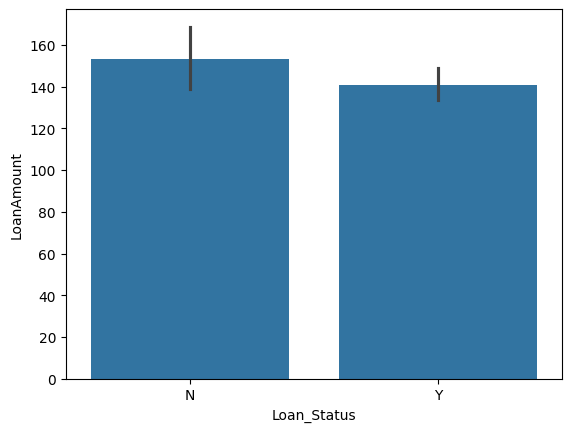

In [122]:
sns.barplot(x=df["Loan_Status"],y=df['LoanAmount'])

In [69]:
df.groupby("Loan_Status")["LoanAmount"].describe().T

Loan_Status,N,Y
count,181.000000,411.000000
mean,151.220994,144.294404
std,85.862783,85.484607
min,9.000000,17.000000
25%,100.000000,100.000000
50%,129.000000,126.000000
75%,176.000000,161.000000
max,570.000000,700.000000


<Axes: xlabel='Loan_Status', ylabel='LoanAmount'>

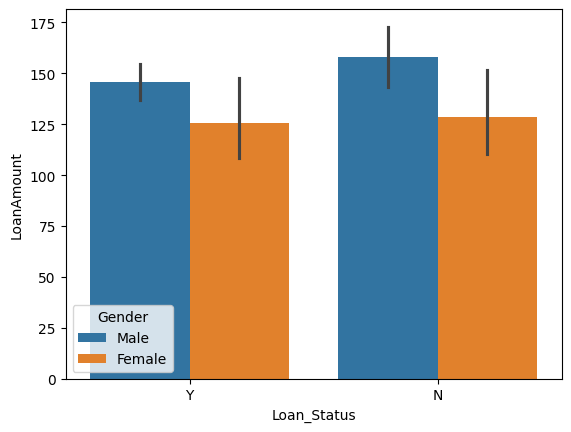

In [70]:
sns.barplot(x=df["Loan_Status"],y=df['LoanAmount'],hue=df['Gender'])

In [124]:
pd.crosstab(df["Gender"],df["Loan_Status"],margins=True,normalize=True)

Loan_Status,N,Y,All
Gender,,,
Female,0.066667,0.112500,0.179167
Male,0.241667,0.579167,0.820833
All,0.308333,0.691667,1.000000


In [73]:
pd.crosstab(df["Education"],df["Loan_Status"],margins=True,normalize=True)

Loan_Status,N,Y,All
Education,,,
Graduate,0.228013,0.553746,0.781759
Not Graduate,0.084691,0.133550,0.218241
All,0.312704,0.687296,1.000000


In [74]:
pd.crosstab(df["Dependents"],df["Loan_Status"],margins=True,normalize=True)

Loan_Status,N,Y,All
Dependents,,,
3,0.030050,0.055092,0.085142
0,0.178631,0.397329,0.575960
1,0.060100,0.110184,0.170284
2,0.041736,0.126878,0.168614
All,0.310518,0.689482,1.000000


In [75]:
pd.crosstab(df["Self_Employed"],df["Loan_Status"],margins=True,normalize=True)

Loan_Status,N,Y,All
Self_Employed,,,
No,0.269759,0.589347,0.859107
Yes,0.044674,0.096220,0.140893
All,0.314433,0.685567,1.000000


In [76]:
pd.crosstab(df["Loan_Amount_Term"],df["Loan_Status"],margins=True,normalize=True)

Loan_Status,N,Y,All
Loan_Amount_Term,,,
12.0,0.000000,0.001667,0.001667
36.0,0.003333,0.000000,0.003333
60.0,0.000000,0.003333,0.003333
84.0,0.001667,0.005000,0.006667
120.0,0.000000,0.005000,0.005000
180.0,0.025000,0.048333,0.073333
240.0,0.001667,0.005000,0.006667
300.0,0.008333,0.013333,0.021667
360.0,0.255000,0.598333,0.853333


In [77]:
pd.crosstab(df["Credit_History"],df["Loan_Status"],margins=True,normalize=True)

Loan_Status,N,Y,All
Credit_History,,,
No,0.145390,0.012411,0.157801
Yes,0.171986,0.670213,0.842199
All,0.317376,0.682624,1.000000


In [78]:
pd.crosstab(df["Property_Area"],df["Loan_Status"],margins=True,normalize=True)

Loan_Status,N,Y,All
Property_Area,,,
Rural,0.112378,0.179153,0.291531
Semiurban,0.087948,0.291531,0.379479
Urban,0.112378,0.216612,0.328990
All,0.312704,0.687296,1.000000


In [79]:
df.groupby("Loan_Status")["overall_income"].describe().T

Loan_Status,N,Y
count,192.000000,422.000000
mean,7323.885417,6888.582938
std,7739.774247,5788.063646
min,1442.000000,1963.000000
25%,4162.750000,4188.750000
50%,5289.500000,5439.000000
75%,7570.750000,7452.500000
max,81000.000000,63337.000000


In [80]:
df['overall_income'].corr(df['LoanAmount'])

np.float64(0.624620796484687)

<Axes: xlabel='overall_income', ylabel='LoanAmount'>

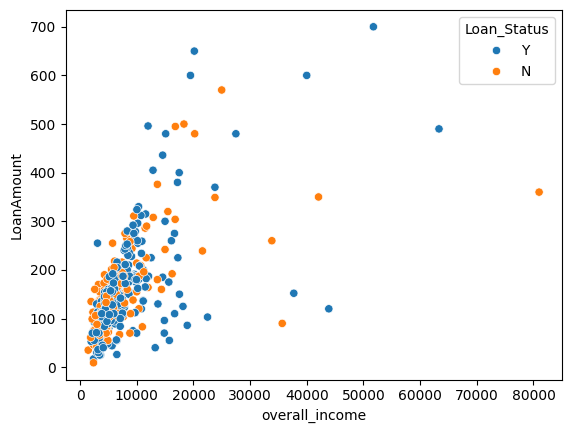

In [81]:
sns.scatterplot(x=df['overall_income'],y=df['LoanAmount'],hue=df['Loan_Status'])

<Axes: xlabel='Credit_History', ylabel='overall_income'>

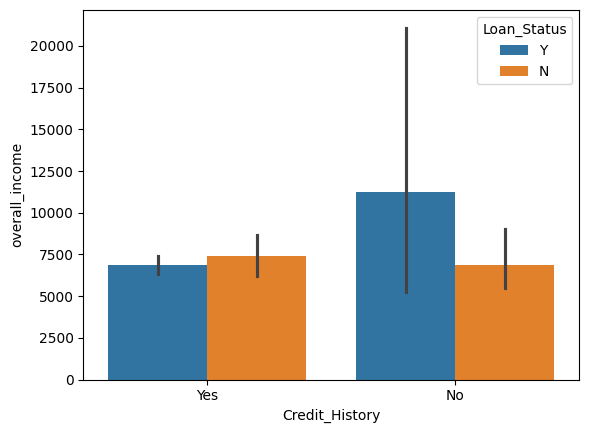

In [83]:
sns.barplot(x=df["Credit_History"],y=df['overall_income'],hue=df['Loan_Status'])

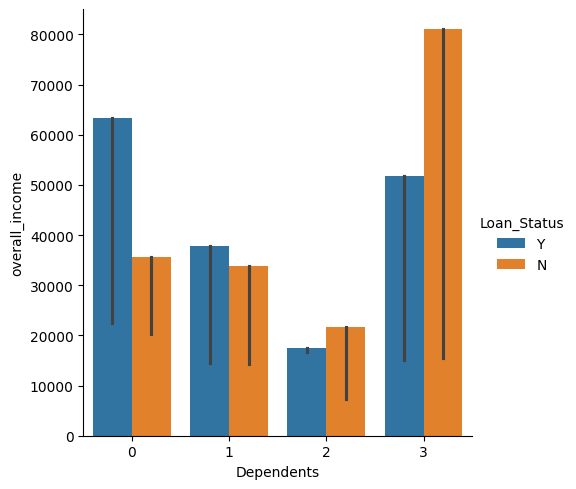

In [84]:
sns.catplot(x=df["Dependents"],y=df['overall_income'],hue=df['Loan_Status'],estimator='max',kind='bar')

In [85]:
pd.crosstab([df['Credit_History'],df['Loan_Status']],df['Dependents'],margins=True)

Dependents                   3    0   1   2  All
Credit_History Loan_Status                      
No             N             9   42  13  13   77
               Y             2    3   1   1    7
Yes            N             7   60  17  12   96
               Y            30  211  59  69  369
All                         48  316  90  95  549